## Importing libraries for data handling, visualization, and modeling


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Dataset

In [7]:

# Load the car dataset into a pandas DataFrame
df = pd.read_csv("data/cardekho.csv")

## Data Cleaning

In [8]:
df['seats'] = df['seats'].fillna(df['seats'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = pd.to_numeric(df['max_power'], errors= 'coerce')
df['max_power'] = df['max_power'].fillna(df['max_power'].mean().round(2))
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(df['mileage(km/ltr/kg)'].median())

In [9]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  8128 non-null   float64
 9   engine              8128 non-null   float64
 10  max_power           8128 non-null   float64
 11  seats               8128 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 762.1+ KB


In [11]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


## Feature Engineering

In [12]:
# Drop the 'name' column since it's not useful for prediction
df = df.drop('name', axis= 1)

In [13]:
# Identify categorical (non-numeric) columns
categorical_cols = df.select_dtypes(exclude= [np.number]).columns
categorical_cols

Index(['fuel', 'seller_type', 'transmission', 'owner'], dtype='object')

In [14]:
# Convert categorical variables into dummy/one-hot encoded features
df_encoded = pd.get_dummies(df, columns= categorical_cols, drop_first= True)
df_encoded.head()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


## Train-test-split

In [15]:
# Separate features (X) and target variable (y)
X = df_encoded.drop('selling_price', axis= 1)
y = df_encoded['selling_price']

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## Model Training and Evaluation

In [17]:
def model_evaluation(model, model_name: str, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions on test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_true= y_test, y_pred= y_pred)
    mse = mean_squared_error(y_true= y_test, y_pred= y_pred)
    rmse = np.sqrt(mean_squared_error(y_true= y_test, y_pred= y_pred))
    r_score  = r2_score(y_true= y_test, y_pred= y_pred)

    # Print model performance
    print(f"{model_name} Performance")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"R^2 score: {r_score}")


    # A visualization of the model’s predictions vs. actual prices.
    sns.scatterplot(x = y_pred, y = y_test)
    plt.title("Actual vs Predicted Car Prices")
    plt.xlabel("Predicted Prices")
    plt.ylabel("Actual Prices")
    plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
    plt.show()


Linear Regression Performance
Mean Squared Error: 198443644836.0346
Mean Absolute Error: 270353.9775981888
Root Mean Squared Error: 445470.1391070277
R^2 score: 0.6972565134978286


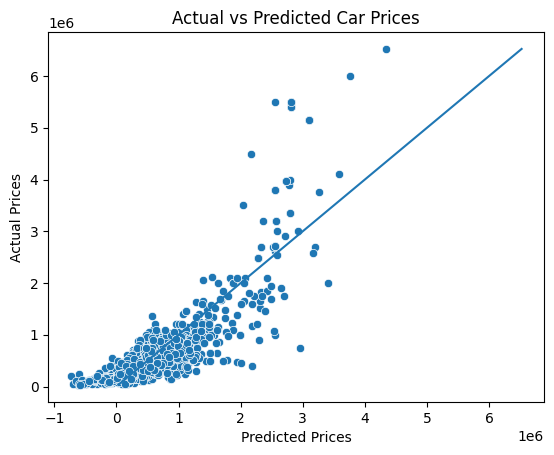

In [18]:
# Linear Regression model
lr = LinearRegression()

model_evaluation(lr, "Linear Regression", X_train, X_test, y_train, y_test)

Random Forest Regressor Performance
Mean Squared Error: 19669275498.557854
Mean Absolute Error: 69678.10414969035
Root Mean Squared Error: 140247.1942626941
R^2 score: 0.9699927652189352


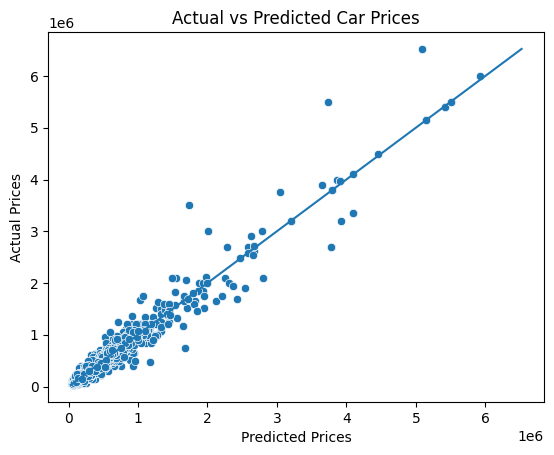

In [19]:
# Random Forest Regressor model
rfr_model = RandomForestRegressor()

model_evaluation(rfr_model, "Random Forest Regressor", X_train, X_test, y_train, y_test)

Gradient Boost Regression Performance
Mean Squared Error: 25798568209.569927
Mean Absolute Error: 93104.02264276928
Root Mean Squared Error: 160619.3270113218
R^2 score: 0.9606419822968751


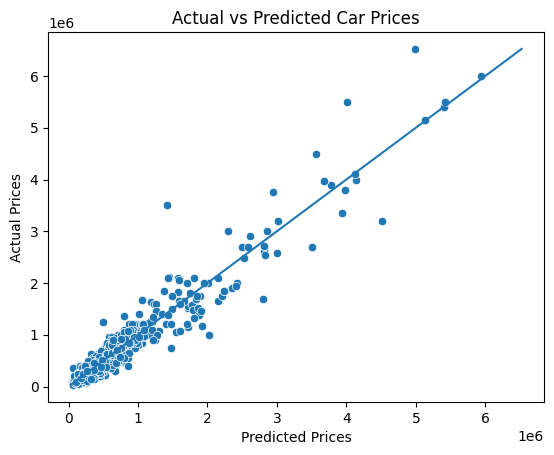

In [20]:
# Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor()

model_evaluation(gbr_model, "Gradient Boost Regression", X_train, X_test, y_train, y_test)

Ridge Regression Performance
Mean Squared Error: 199414793751.26718
Mean Absolute Error: 270662.4064985827
Root Mean Squared Error: 446558.8357106678
R^2 score: 0.6957749391760446


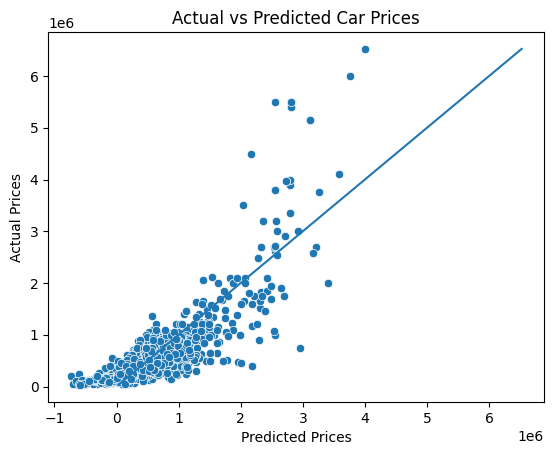

In [21]:
# Ridge Regression model
ridge = Ridge(alpha=1.0)


model_evaluation(ridge, "Ridge Regression", X_train, X_test, y_train, y_test)